## Configuration

In [15]:
CFG = {
    'seed': 42,
    'model_name': 'efficientnet_b0', # Change this to 'efficientnet_b0' later
    'save_path' : '/kaggle/working/',
    'model_title': 'efficientnet_b0_v1.pth',
    'img_size': 224,          # EfficientNet-B0 also uses 224x224
    'batch_size': 8,
    'epochs': 8,
    'lr': 1e-4,
    'weight_decay': 1e-5,
    'num_classes': 3,
    'num_workers': 0
}

## Loading the Stratified Split Metadata

In [16]:
import pandas as pd
import os

# 1. Get the Labels from your Preprocessing output
# (Just unzip the SMALL output.zip for the CSVs)
!unzip -q /kaggle/input/notebooks/tatumsoward/aig210-galaxyzoopreprocessing/_output_.zip -d /kaggle/temp/

# 2. Path to your pre-split CSV
TRAIN_CSV = '/kaggle/temp/train_split.csv'

# 3. Path to the ORIGINAL images (Mount the dataset for this!)
# Change this path to the exact location of the dataset ZIP
IMG_ZIP = '/kaggle/input/competitions/galaxy-zoo-the-galaxy-challenge/images_training_rev1.zip'

# 4. Unzip the images ONLY to the fast temp directory
!unzip -q {IMG_ZIP} -d /kaggle/temp/images/

BASE_PATH = '/kaggle/temp/'
IMG_DIR = os.path.join(BASE_PATH, 'images_training_rev1', 'images_training_rev1')

print("CSVs and Images are now linked and ready in /kaggle/temp/")

replace /kaggle/temp/norm_stats.json? [y]es, [n]o, [A]ll, [N]one, [r]ename: ^C
replace /kaggle/temp/images/images_training_rev1/100008.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: ^C
CSVs and Images are now linked and ready in /kaggle/temp/


✅ CSV Found! Training rows: 16423
✅ Image Folder Found! Total files: 61578


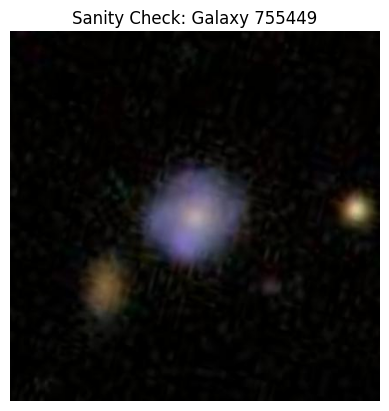

In [17]:
#Data Loaded Sanity Check

import os
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

# 1. Check if the CSVs exist
csv_path = '/kaggle/temp/train_split.csv'
if os.path.exists(csv_path):
    train_df = pd.read_csv(csv_path)
    print(f"✅ CSV Found! Training rows: {len(train_df)}")
else:
    print("❌ CSV MISSING! Check your unzip path.")

# 2. Check the Image folder
# Note: Unzipping 'images_training_rev1.zip' usually creates a nested folder
img_dir = '/kaggle/temp/images/images_training_rev1' 

if os.path.exists(img_dir):
    num_images = len(os.listdir(img_dir))
    print(f"✅ Image Folder Found! Total files: {num_images}")
    
    # 3. Pull a random sample for a "Visual Check"
    sample_id = train_df.iloc[0]['GalaxyID']
    sample_path = os.path.join(img_dir, f"{sample_id}.jpg")
    
    if os.path.exists(sample_path):
        img = Image.open(sample_path)
        plt.imshow(img)
        plt.title(f"Sanity Check: Galaxy {sample_id}")
        plt.axis('off')
        plt.show()
    else:
        print(f"❌ Image file {sample_id}.jpg not found inside {img_dir}")
else:
    print(f"❌ Image directory {img_dir} is missing!")


## Preparing the Data for the Model

### Transformations and Data Augmentation

In [18]:
import json

# 1. Load the stats from the same temp directory as your CSVs
stats_path = '/kaggle/temp/norm_stats.json'

with open(stats_path, 'r') as f:
    norm_dict = json.load(f)

GALAXY_MEAN = norm_dict['mean']
GALAXY_STD = norm_dict['std']

print(f"✅ Loaded Normalization Stats:")
print(f"Mean: {GALAXY_MEAN}")
print(f"Std:  {GALAXY_STD}")

✅ Loaded Normalization Stats:
Mean: [0.0462644841195366, 0.04110195352379381, 0.030947859142717995]
Std:  [0.0896679521649469, 0.0753237875670829, 0.0674412436919027]


In [19]:
from torchvision import transforms

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0), ratio=(0.9, 1.1)), #for EfficiNet
    #transforms.CenterCrop(CFG['img_size']), # for ResNet
    transforms.RandomRotation(180), # Galaxies can be at any angle!
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(), #for EfficiNet
    transforms.ToTensor(),
    transforms.Normalize(mean=GALAXY_MEAN, std=GALAXY_STD)
])

val_transforms = transforms.Compose([
    transforms.CenterCrop(CFG['img_size']),
    transforms.ToTensor(),
    transforms.Normalize(mean=GALAXY_MEAN, std=GALAXY_STD)
])

### Weighted Sampler for Class Imbalance

In [20]:
import torch
from torch.utils.data import WeightedRandomSampler

# Double-check this part of your code:
class_counts = train_df['label'].value_counts()
weights = 1.0 / class_counts
sample_weights = [weights[label] for label in train_df['label']]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(train_df), # <--- MUST match len(train_dataset)
    replacement=True
)

print(f"Sampler initialized for {len(class_counts)} classes.")

Sampler initialized for 3 classes.


### Initializing Data Class

In [21]:
import pandas as pd
from torch.utils.data import Dataset
from PIL import Image

# Update your paths to point to the TEMP directory
BASE_PATH = '/kaggle/temp/'
TRAIN_CSV = os.path.join(BASE_PATH, 'train_split.csv')
# Note: Unzipping 'images_training_rev1.zip' usually creates a subfolder with the same name
IMG_DIR = os.path.join(BASE_PATH, 'images_training_rev1', 'images_training_rev1')

class GalaxyDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        # Read and force a clean integer index
        self.df = pd.read_csv(csv_file).reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        # Ensure keys match exactly what is in your CSV
        self.label_map = {'Elliptical': 0, 'Spiral': 1, 'Irregular': 2}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # FORCE idx to be a Python int. 
        # Sometimes Samplers pass a numpy.int64 which can cause indexing bugs.
        if hasattr(idx, 'item'):
            idx = idx.item()
        idx = int(idx)

        row = self.df.iloc[idx]
        
        # 1. Handle Label (The most likely source of 'string index' errors)
        label_name = str(row['label']) 
        label = self.label_map[label_name]
        
        # 2. Handle Image ID
        img_id = str(int(row['GalaxyID']))
        img_path = os.path.join(self.img_dir, f"{img_id}.jpg")
        
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

In [22]:
# 1. Initialize Dataset Objects
# These use the GalaxyDataset class we defined earlier
train_dataset = GalaxyDataset(
    csv_file=TRAIN_CSV, 
    img_dir=IMG_DIR, 
    transform=train_transforms
)

val_dataset = GalaxyDataset(
    csv_file=os.path.join(BASE_PATH, 'val_split.csv'), 
    img_dir=IMG_DIR, 
    transform=val_transforms
)

## Loading the Data

In [23]:
from torch.utils.data import DataLoader
train_df_clean = train_dataset.df.reset_index(drop=True)
train_dataset.df = train_df_clean # Force alignment

counts = train_df_clean['label'].value_counts()
weights_map = 1.0 / counts
sample_weights = train_df_clean['label'].map(weights_map).values

sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(train_df_clean),
    replacement=True
)

# 3. Create the DataLoaders
# The training loader uses the sampler; the validation loader just shuffles normally
train_loader = DataLoader(
    train_dataset, 
    batch_size=CFG['batch_size'], 
    sampler=sampler,
    num_workers=CFG['num_workers'],
    pin_memory=False # Changed to False # Speeds up transfer to GPU
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=CFG['batch_size'], 
    shuffle=False, 
    num_workers=CFG['num_workers'],
    pin_memory=False # Changed to False
)

print(f"✅ DataLoaders Ready!")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

✅ DataLoaders Ready!
Training samples: 16423
Validation samples: 2053


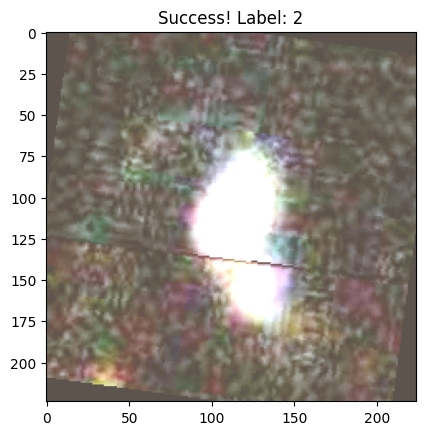

In [24]:
import matplotlib.pyplot as plt

# Try to grab one actual image from the loader
try:
    images, labels = next(iter(train_loader))
    # Undo normalization for display
    img = images[0].permute(1, 2, 0).numpy()
    img = img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
    
    plt.imshow(img.clip(0, 1))
    plt.title(f"Success! Label: {labels[0].item()}")
    plt.show()
except Exception as e:
    print(f"❌ Path is still broken: {e}")

## Initializing the Model

In [25]:
import torch.nn as nn
from torchvision import models

# 1. Determine the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Initialize the model based on CFG
if CFG['model_name'] == 'resnet18':
    model = models.resnet18(weights='IMAGENET1K_V1')
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, CFG['num_classes'])
    
elif 'efficientnet' in CFG['model_name']:
    # Placeholder for when you switch
    model = models.efficientnet_b0(weights='IMAGENET1K_V1')
    num_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(num_features, CFG['num_classes'])

model = model.to(device)
print(f"Model '{CFG['model_name']}' loaded and moved to {device}")

Model 'resnet18' loaded and moved to cuda


In [26]:
import torch.optim as optim

# Loss function stays standard for 3 classes
criterion = nn.CrossEntropyLoss()

# Optimizer pulls values from CFG
optimizer = optim.Adam(
    model.parameters(), 
    lr=CFG['lr'], 
    weight_decay=CFG['weight_decay']
)

## Training the Model

### Training/Validation Definitions

In [27]:
import torch
from tqdm.auto import tqdm # For a nice progress bar

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in tqdm(loader, desc="Training", leave=False):
        images, labels = images.to(device), labels.to(device)
        
        # 1. Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # 2. Backward pass
        loss.backward()
        optimizer.step()
        
        # 3. Statistics
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    return running_loss / total, 100. * correct / total

def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad(): # No gradients needed for validation
        for images, labels in tqdm(loader, desc="Validating", leave=False):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
    return running_loss / total, 100. * correct / total

### Main Execution Loop

In [28]:
# Storage for plotting later
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

best_val_acc = 0.0

for epoch in range(1, CFG['epochs'] + 1):
    # Run loops
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = validate_one_epoch(model, val_loader, criterion, device)
    
    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    print(f"Epoch [{epoch}/{CFG['epochs']}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    
    # Save Best Model Checkpoint
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        save_path = os.path.join(CFG['save_path'], CFG['model_title'])
        torch.save(model.state_dict(), save_path)
        print(f"--- New Best Model Saved (Acc: {val_acc:.2f}%) ---")
    print("-" * 30)

Training:   0%|          | 0/2053 [00:00<?, ?it/s]

Validating:   0%|          | 0/257 [00:00<?, ?it/s]

Epoch [1/8]
Train Loss: 0.4902 | Train Acc: 79.58%
Val Loss: 0.3246 | Val Acc: 87.58%
--- New Best Model Saved (Acc: 87.58%) ---
------------------------------


Training:   0%|          | 0/2053 [00:00<?, ?it/s]

Validating:   0%|          | 0/257 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/257 [00:00<?, ?it/s]

Epoch [7/8]
Train Loss: 0.2285 | Train Acc: 91.43%
Val Loss: 0.2111 | Val Acc: 91.18%
------------------------------


Training:   0%|          | 0/2053 [00:00<?, ?it/s]

Validating:   0%|          | 0/257 [00:00<?, ?it/s]

Epoch [8/8]
Train Loss: 0.2217 | Train Acc: 91.68%
Val Loss: 0.2110 | Val Acc: 91.57%
------------------------------


## Metrics and Evaluation

### Initializing Testing Set

In [29]:
# 1. Create the Test Dataset Instance
# Use the same transforms as your validation set (no augmentation)
test_dataset = GalaxyDataset(
    csv_file=os.path.join(BASE_PATH, 'test_split.csv'), 
    img_dir=IMG_DIR, 
    transform=val_transforms
)

# 2. Create the Test Loader
test_loader = DataLoader(
    test_dataset, 
    batch_size=CFG['batch_size'], 
    shuffle=False, # Crucial: Keep order for the confusion matrix
    num_workers=CFG['num_workers'],
    pin_memory=False
)

print(f"✅ Test Loader Ready with {len(test_dataset)} images.")

✅ Test Loader Ready with 2053 images.


### Loading Best Model Weights

In [30]:
# 1. Re-initialize the architecture
test_model = models.resnet18(weights=None) # No need for ImageNet weights now
test_model.fc = nn.Linear(test_model.fc.in_features, CFG['num_classes'])

# 2. Load the saved weights
model_path = os.path.join(CFG['save_path'], CFG['model_title'])
test_model.load_state_dict(torch.load(model_path, map_location=device))

# 3. Move to GPU and set to EVAL mode
test_model = test_model.to(device)
test_model.eval()

print(f"✅ Loaded best model weights from: {CFG['model_title']}")

✅ Loaded best model weights from: resnet18_baseline.pth


### Testing Loop

In [32]:
import numpy as np

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Final Evaluation"):
        images = images.to(device)
        
        # Get predictions
        outputs = test_model(images)
        _, predicted = torch.max(outputs, 1)
        
        # Move back to CPU and store
        y_true.extend(labels.numpy())
        y_pred.extend(predicted.cpu().numpy())

# Convert to numpy arrays for the dashboard
y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("✅ Evaluation Complete!")

Final Evaluation:   0%|          | 0/257 [00:00<?, ?it/s]

✅ Evaluation Complete!


### Report

In [33]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def create_performance_dashboard(history, y_true, y_pred, model_name, save_path=None):
    """
    Creates a single dashboard image combining Loss, Accuracy, Confusion Matrix, and Classification Report.
    """
    target_names = ['Elliptical', 'Spiral', 'Irregular']
    
    # 1. Setup the figure and grid (2 rows, 2 columns)
    # We make the figure extra wide/tall to fit everything clearly
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    plt.suptitle(f'Model Performance Dashboard: {model_name}', fontsize=22, fontweight='bold', y=0.98)
    
    # Use a professional style
    plt.style.use('seaborn-v0_8-whitegrid')
    
    # Extract specific axes
    ax_loss, ax_acc = axes[0, 0], axes[0, 1]
    ax_cm, ax_report = axes[1, 0], axes[1, 1]
    
    # --- A. Plot Loss Curves (Top Left) ---
    epochs = range(1, len(history['train_loss']) + 1)
    ax_loss.plot(epochs, history['train_loss'], '-o', label='Train Loss', color='#3498db', linewidth=2, markersize=4)
    ax_loss.plot(epochs, history['val_loss'], '-o', label='Val Loss', color='#e74c3c', linewidth=2, markersize=4)
    ax_loss.set_title('Training & Validation Loss', fontsize=16)
    ax_loss.set_xlabel('Epochs')
    ax_loss.set_ylabel('Cross Entropy Loss')
    ax_loss.legend(fontsize=12)
    ax_loss.grid(True, linestyle='--', alpha=0.7)

    # --- B. Plot Accuracy Curves (Top Right) ---
    best_epoch = np.argmax(history['val_acc'])
    best_val = history['val_acc'][best_epoch]
    
    ax_acc.plot(epochs, history['train_acc'], '-o', label='Train Acc', color='#3498db', linewidth=2, markersize=4)
    ax_acc.plot(epochs, history['val_acc'], '-o', label='Val Acc', color='#e74c3c', linewidth=2, markersize=4)
    
    # Mark the best validation point
    ax_acc.scatter(best_epoch + 1, best_val, color='black', s=100, zorder=5)
    ax_acc.annotate(f'Best Val: {best_val:.1f}%', 
                     xy=(best_epoch + 1, best_val), 
                     xytext=(best_epoch + 1, best_val - 8),
                     arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
                     horizontalalignment='center', fontsize=12, fontweight='bold')
    
    ax_acc.set_title('Training & Validation Accuracy', fontsize=16)
    ax_acc.set_xlabel('Epochs')
    ax_acc.set_ylabel('Accuracy (%)')
    ax_acc.legend(fontsize=12)
    ax_acc.grid(True, linestyle='--', alpha=0.7)

    # --- C. Confusion Matrix (Bottom Left) ---
    cm = confusion_matrix(y_true, y_pred)
    # Calculate percentages for alternative view if needed, but counts are standard
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=target_names, yticklabels=target_names,
                ax=ax_cm, annot_kws={"size": 16, "fontweight": 'bold'})
    
    ax_cm.set_title('Confusion Matrix (Test Data)', fontsize=16)
    ax_cm.set_ylabel('Actual Class', fontsize=14)
    ax_cm.set_xlabel('Predicted Class', fontsize=14)
    ax_cm.tick_params(axis='both', which='major', labelsize=12)

    # --- D. Classification Report (Bottom Right) ---
    # This is the tricky part: turning text into a plot element
    report = classification_report(y_true, y_pred, target_names=target_names, digits=3)
    
    # Clean up the axes (hide grid, spines, ticks)
    ax_report.axis('off')
    ax_report.set_title('Classification Report (Test Data)', fontsize=16)
    
    # Add the text with a monospace font so the columns align perfectly
    ax_report.text(0.05, 0.95, report, 
                   fontsize=13, 
                   family='monospace', # CRUCIAL for alignment
                   transform=ax_report.transAxes, 
                   verticalalignment='top')

    # --- Final Touches ---
    plt.tight_layout(rect=[0, 0.03, 1, 0.97]) # Adjust layout to fit main title
    
    # Save if a path is provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Dashboard saved to: {save_path}")
    
    plt.show()

✅ Dashboard saved to: /kaggle/working/resnet18_dashboard.png


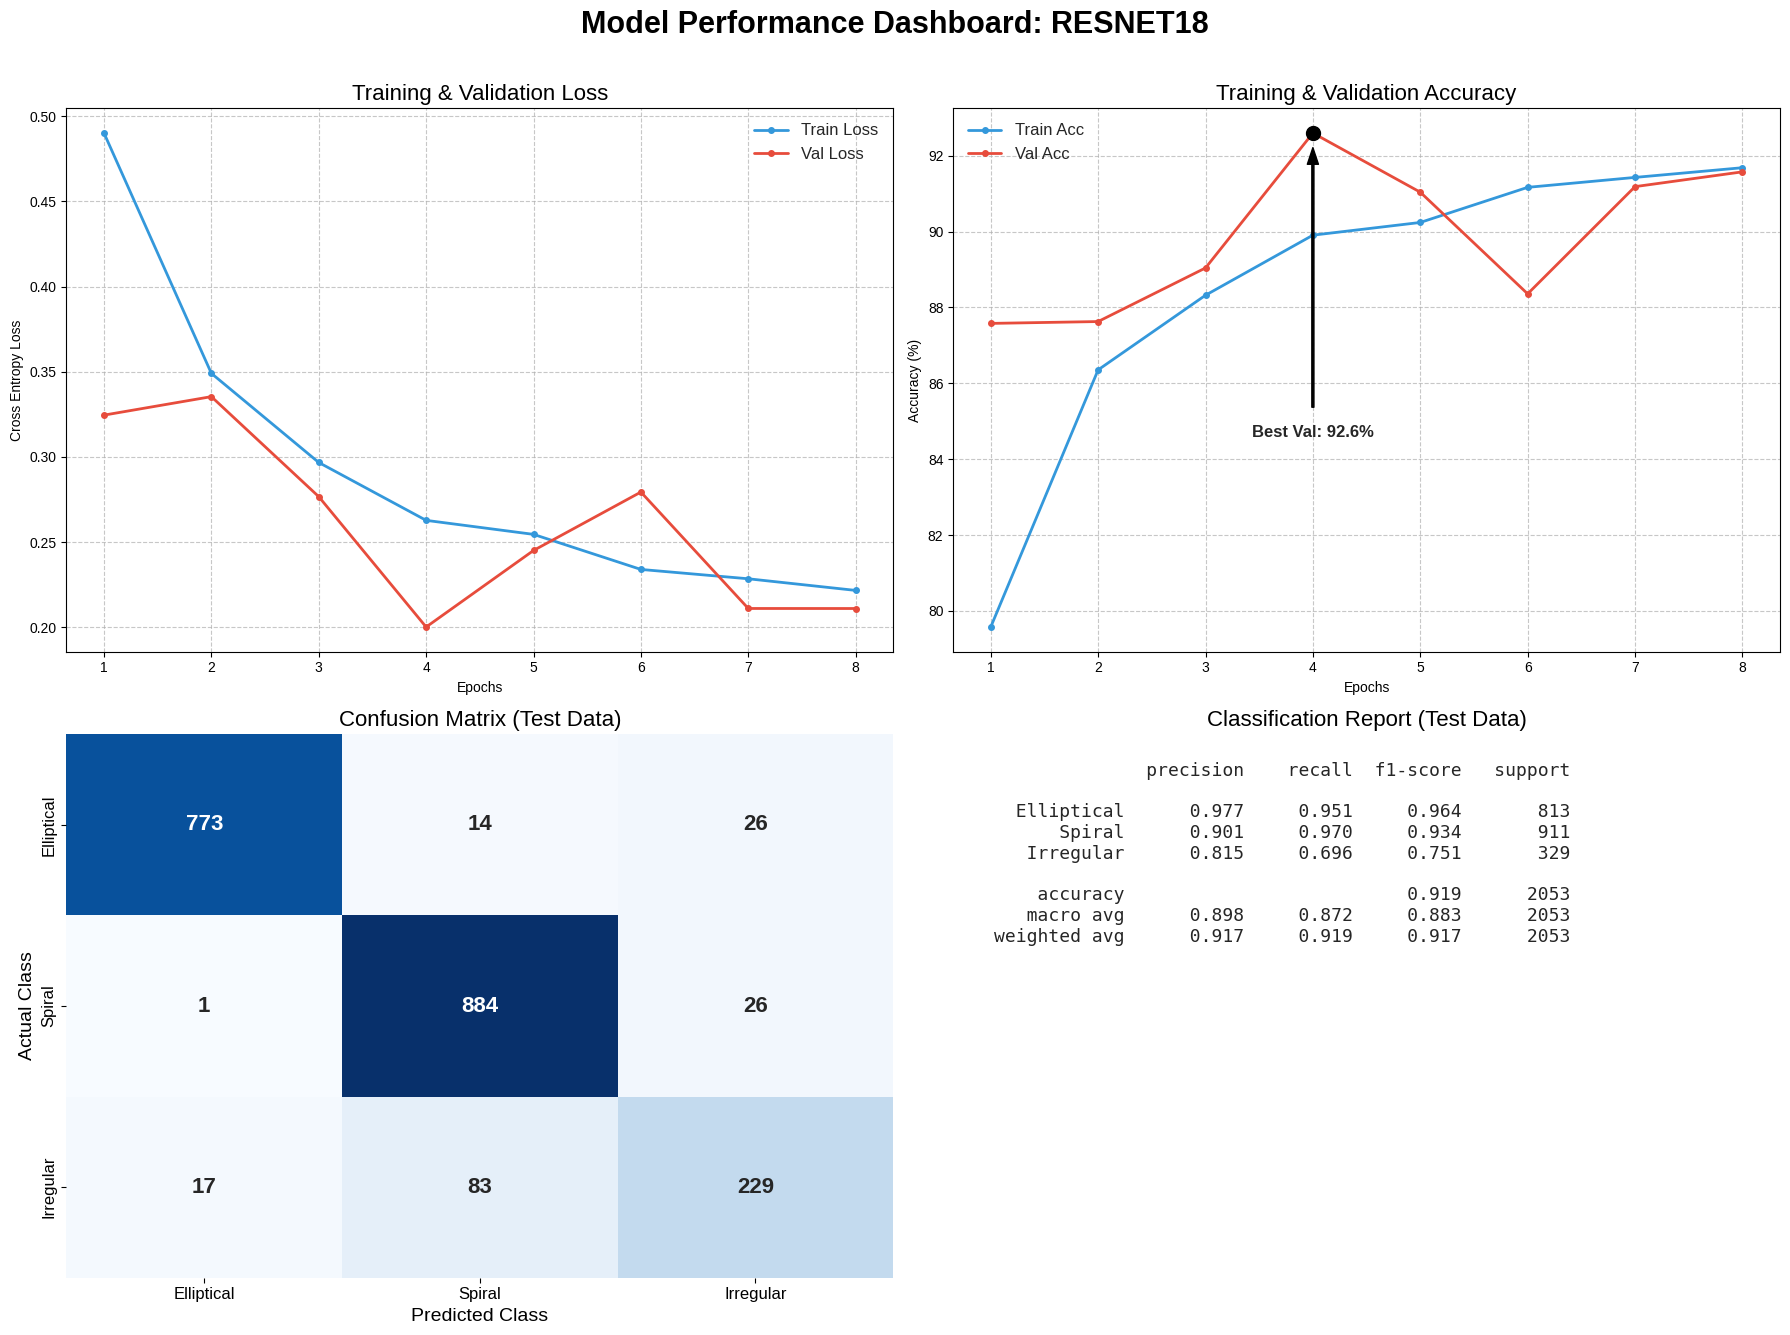

In [34]:
# Assuming you just finished evaluate_on_test() from the previous step
# and have y_true and y_pred as numpy arrays or lists

dashboard_filename = os.path.join(CFG['save_path'], f"{CFG['model_name']}_dashboard.png")

create_performance_dashboard(
    history=history, 
    y_true=np.array(y_true), # Ensure they are numpy arrays
    y_pred=np.array(y_pred), 
    model_name=CFG['model_name'].upper(),
    save_path=dashboard_filename
)